# Clustering Christenson Transcription

In [2]:
import pandas as pd
import numpy as np
import plotly_express as px

In [3]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.preprocessing import normalize

In [4]:
import sys
sys.path.append("../../local_lib/")
from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

# Get Data

In [47]:
DOC = pd.read_csv("christenson-quiche-PARA.csv").set_index("para_num")

In [48]:
DOC

,doc_str,n_chars
para_num,,
0,ARE V XE OHER,13
1,Tzih varal Quiche vbi.,22
2,Varal xchicatzibah vi xchicatiquiba vi oher tz...,1215
3,"ARE V TZIHOXIC VAE Cacatzinin oc, caca chamam ...",110
4,Vae cute nabe tzih nabe vchan. mahabi oε hun v...,731
...,...,...
104,unim ha. Hacavitz cut vcah ahau hun,35
105,vnim ha chi cahibcut nimha,26
106,chuvach ahau quiche,19


# CHUNK

In [561]:
# bigline = (' '.join(DOC.doc_str.to_list()))
# chunk_size = len(bigline) // 100
# CHUNK = pd.DataFrame([bigline[i:i + chunk_size] for i in range(0, len(bigline), chunk_size)], columns=['chunk_str'])

In [595]:
bigline = (' '.join(DOC.doc_str.to_list())).split()
chunk_size = len(bigline) // 80 # 75 # 50
chunks = [bigline[i:i + chunk_size] for i in range(0, len(bigline), chunk_size)]
CHUNK = pd.DataFrame(chunks).apply(lambda x: ' '.join(map(str, x)), axis=1).to_frame('chunk_str')

In [596]:
CHUNK['level_1'] = CHUNK.index // 10
CHUNK['level_2'] = CHUNK.index % 10
CHUNK = CHUNK.reset_index(drop=True).set_index(['level_1', 'level_2'])
# CHUNK.index.name = 'chunk_id'
CHUNK['n_chars'] = CHUNK.chunk_str.str.len()

In [597]:
CHUNK.tail()

chunk_str  n_chars
level_1 level_2                                                            
7       6        εalel ahpop re εalem pa huhun chi huyub vacami...     1989
        7        vleu, at yaol rech εanal raxal at pu yaol mial...     1940
        8        cumal maui atan xvinaquiric qui εaεal. ca cucu...     2029
        9        chi nimha are nabe xchicabÿh vleabal rib ahaua...     1854
8       0        quiche ri rumal mahabi chi ilbal re, qonabe oh...     1697

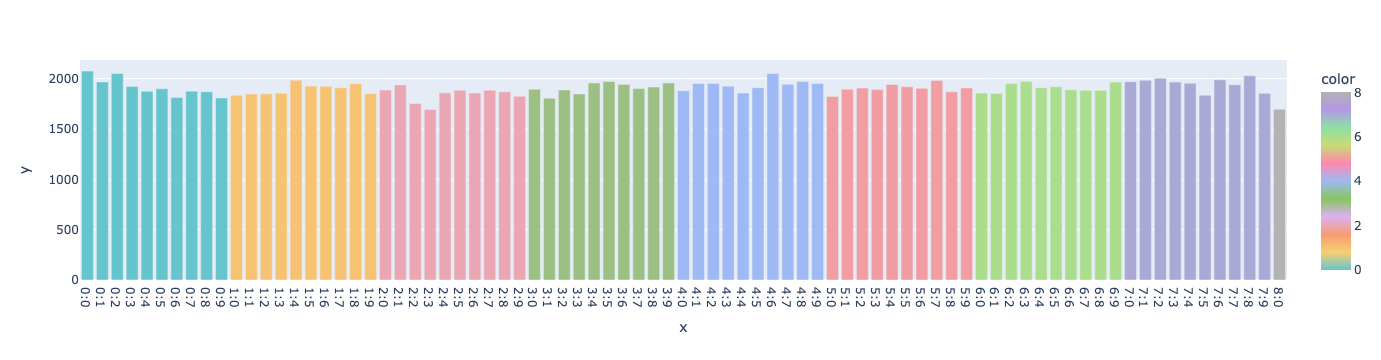

In [598]:
px.bar(x=[f"{idx[0]}:{idx[1]}" for idx in CHUNK.index.to_list()], y=CHUNK.n_chars, color=CHUNK.reset_index().level_1, 
      color_continuous_scale = px.colors.qualitative.Pastel)

# Create CTM

CTM means Chunk-Term Matrix..

In [599]:
# STOPS = VOCAB[VOCAB.stop == True].index.to_list()

In [600]:
count_engine = CountVectorizer(
    lowercase=True,
    analyzer='word',
    token_pattern=r"(?u)\b[a-z'][a-z']+\b",
    max_df=.9,
    min_df=5, 
    # stop_words=STOPS,
    ngram_range = (1,2)
)

In [601]:
CTM = pd.DataFrame(count_engine.fit_transform(CHUNK.chunk_str).toarray(), 
    columns=count_engine.get_feature_names_out(), 
    index=CHUNK.index)

In [602]:
CTM.head()

abah  acab  acab mahucutah  acanoc  acaroc  achih  ah  \
level_1 level_2                                                          
0       0           1     0               0       0       0      0   2   
        1           0     0               0       0       0      0   0   
        2           0     0               0       0       0      0   0   
        3           0     0               0       0       0      0  16   
        4           0     0               0       0       0      1   2   

                 ah cahb  ah labal  ah quixb  ...  zaquil  zaquiric  zaquiroc  \
level_1 level_2                               ...                               
0       0              0         0         0  ...       4         0         0   
        1              0         0         0  ...       0         0         1   
        2              0         0         0  ...       0         0         0   
        3              0         0         0  ...       0         1         1   
        4              0         0         0  ...       0         0         1   

                 zcaquin  zcaquin chic  zipacna  zital  zivan  ztayul  zu  
level_1 level_2                                                            
0       0              0             0        0      0      1       0   0  
        1              0             0        0      0      0       0   0  
        2              0             0        0      0      2       0   0  
        3              0             0        0      0      0       0   0  
        4              0             0        0      0      0       0   0  

[5 rows x 891 columns]

# Create TFIDF

In [603]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True)
TFIDF_CHUNK = pd.DataFrame(tfidf_engine.fit_transform(CTM).toarray(), columns=CTM.columns, index=CTM.index)

# Compute NMF

In [604]:
n_topics = 5
nmf_engine = NMF(n_components=n_topics, max_iter=1000)
VS = TFIDF_CHUNK
THETA = pd.DataFrame(nmf_engine.fit_transform(VS), index=VS.index)
PHI = pd.DataFrame(nmf_engine.components_, columns=VS.columns)
n_terms = 4
TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_terms).index)).T.to_frame('top_terms')
TOPIC

,top_terms
0,"hun, xibalba, came, ahpu"
1,"balam, amac, tohil, quitze"
2,"ahau, ahauab, ahpop, quiche"
3,"cah, vinac, ah, vleu"
4,"qaholab, zipacna, caquix, vvcub caquix"


In [605]:
PHIN = PHI + .01

PW = PHIN.sum() / PHIN.sum().sum()
PTw = (PHIN / PHIN.sum()).T
PT = (PHIN.T.sum() / PHIN.T.sum().sum())
PHI_DST = PTw * np.log(PTw/PT)
PHI_SAL = PHI_DST.T * PW
TOPIC['top_sal'] = PHI_SAL.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_terms).index)).T

λ = .5
PHI_REL = λ * np.log(PHIN) + (1 - λ) * np.log(PHIN/PW)
TOPIC['top_rel'] = PHI_REL.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_terms).index)).T

In [606]:
TOPIC

,top_terms,top_sal,top_rel
0,"hun, xibalba, came, ahpu","xibalba, came, hun, hun came","xibalba, came, hun, hun came"
1,"balam, amac, tohil, quitze","balam, tohil, amac, quitze","balam, tohil, amac, quitze"
2,"ahau, ahauab, ahpop, quiche","ahau, ahauab, ahpop, quiche","ahau, ahauab, ahpop, quiche"
3,"cah, vinac, ah, vleu","cah, bit, tzacol bitol, bitol","cah, bit, tzacol bitol, tzacol"
4,"qaholab, zipacna, caquix, vvcub caquix","zipacna, caquix, qaholab, vvcub caquix","zipacna, caquix, vvcub caquix, qaholab"


# View Topics over Narrative Time

In [607]:
x_axis_labels = [f"{idx[0]}:{idx[1]}" for i, idx in enumerate(THETA.T.columns.to_list())]
y_axis_labels =[f"{i}:{t}" for i, t in enumerate(TOPIC.top_terms.to_list())]

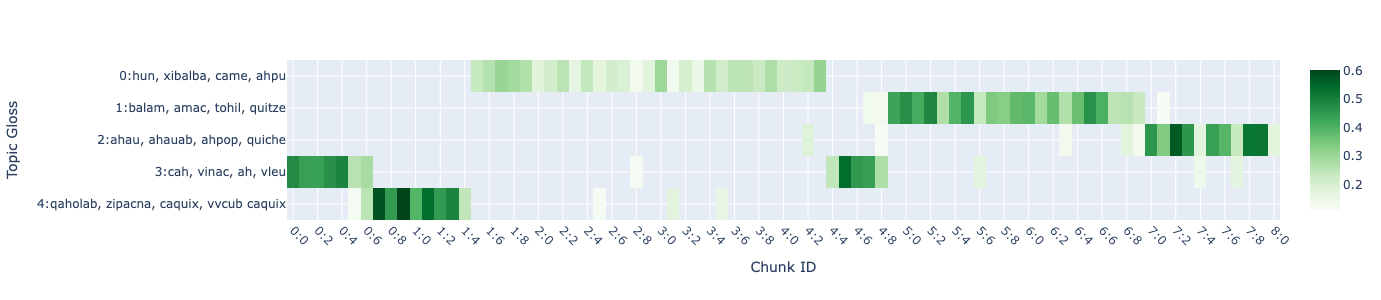

In [608]:
thresh = .11 # .08 #THETA.mean().mean()
px.imshow(THETA[THETA >= thresh].T, 
    x = x_axis_labels,
    y = y_axis_labels,
    color_continuous_scale=px.colors.sequential.Greens, 
    height=300, width=1200, aspect='auto')\
    .update_layout(
        xaxis_title="Chunk ID",
        yaxis_title="Topic Gloss",
        xaxis={ 'tickangle': 45},
        yaxis={ 'tickangle': 0}
)

## Distribution of Max Topic of Narrative Time

In [609]:
CHUNK['max_topic'] = THETA.idxmax(1).to_frame('max_topic')

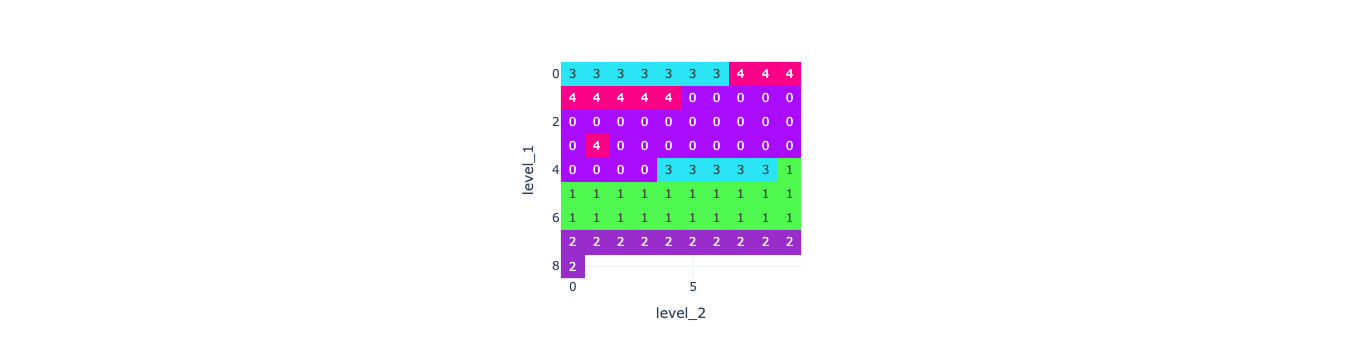

In [610]:
plot_grid(CHUNK.max_topic.unstack())

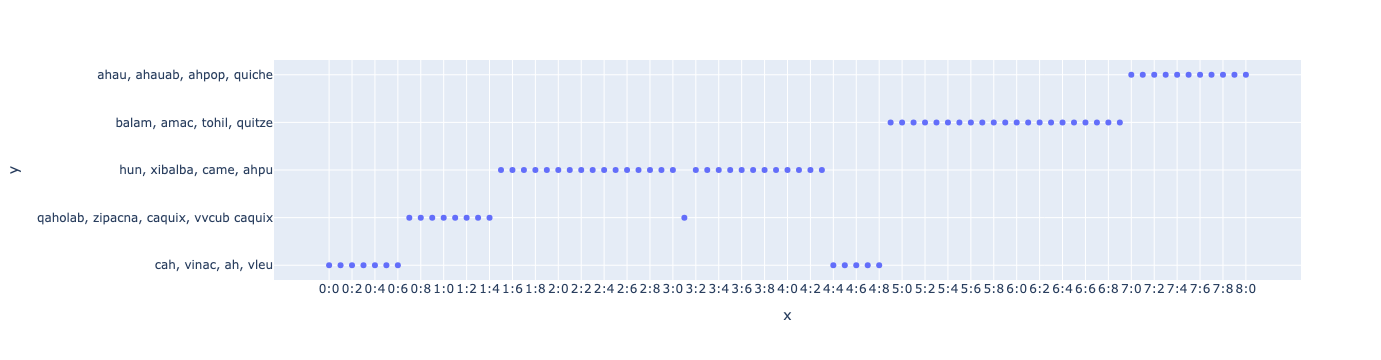

In [611]:
px.scatter(
    x = x_axis_labels, 
    y = [TOPIC.loc[t].top_terms for t in CHUNK.max_topic]
)

# Cluster Docs by Topics

In [612]:
metric = 'euclidean' # "euclidean", "l1", "l2", "manhattan", "cosine", or "precomputed"
linkage = 'ward' # 'ward', 'complete', 'average', 'single'

<Figure size 640x480 with 0 Axes>

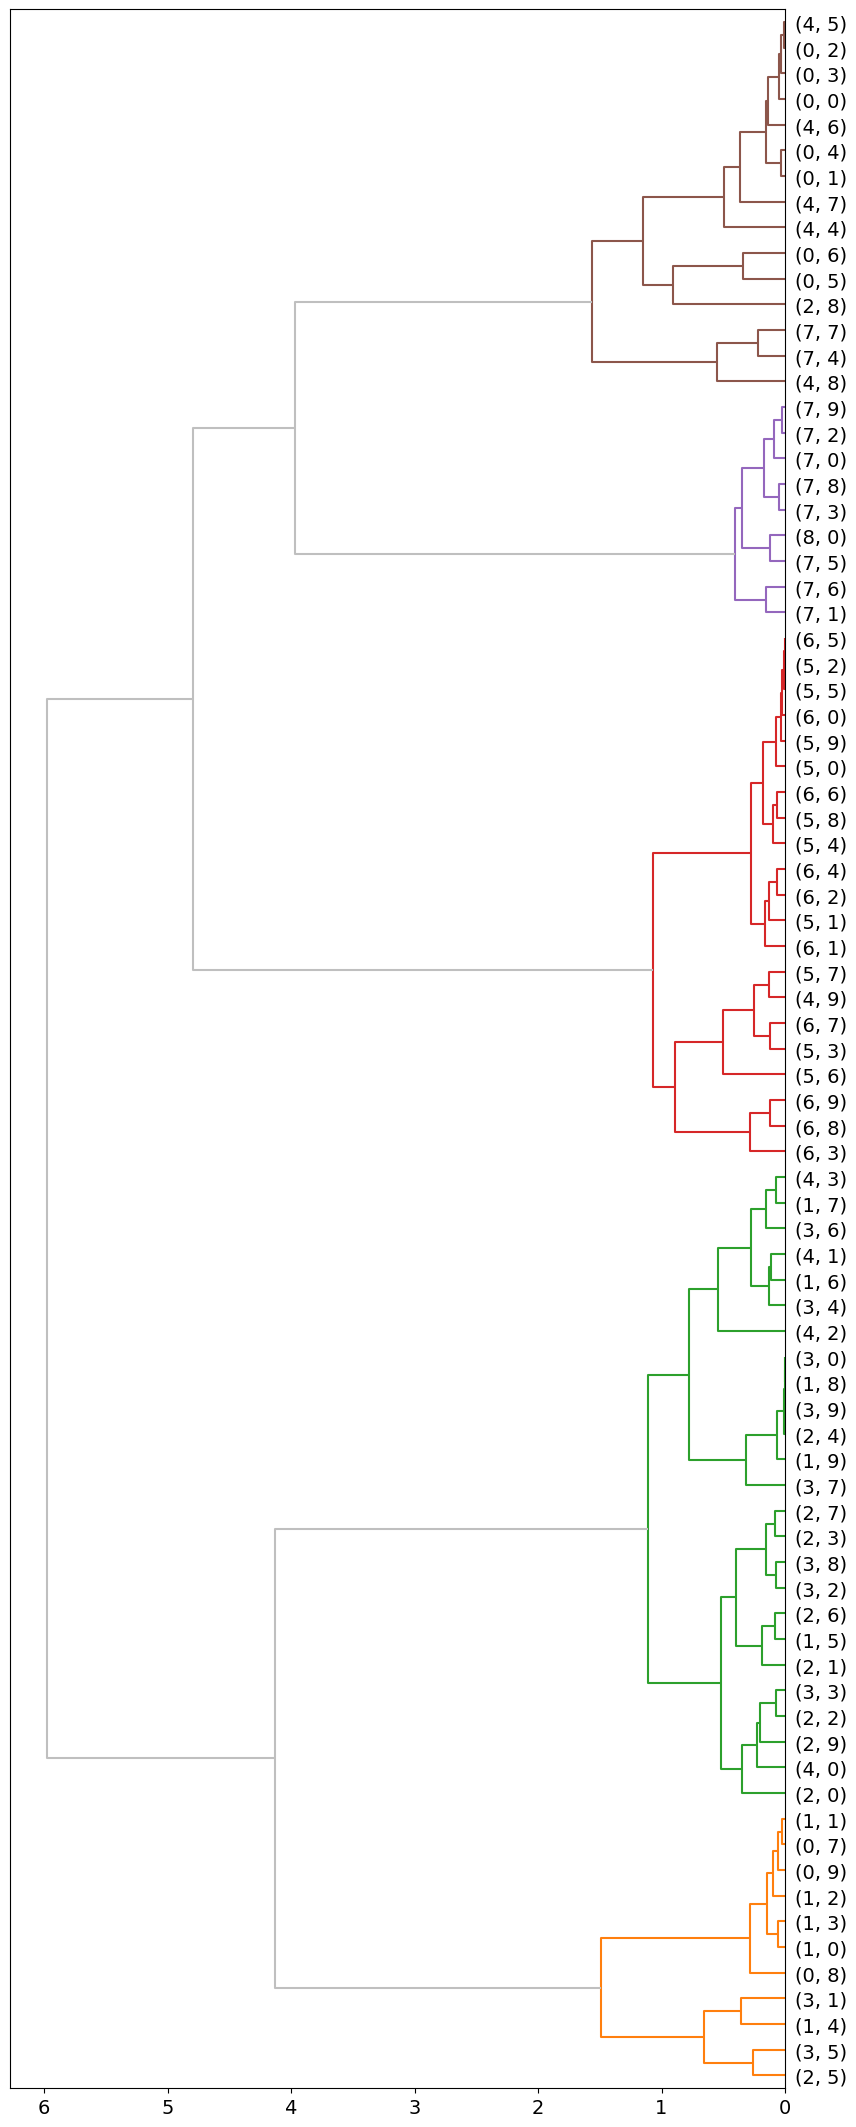

In [613]:
fig1 = HAC(THETA)
fig1.linkage_method = linkage
fig1.dist_metric = metric
fig1.color_thresh = 2
fig1.plot()

In [614]:
fig1.get_cluster_labels()
CHUNK['topic_group'] = fig1.CLUSTER_LABELS

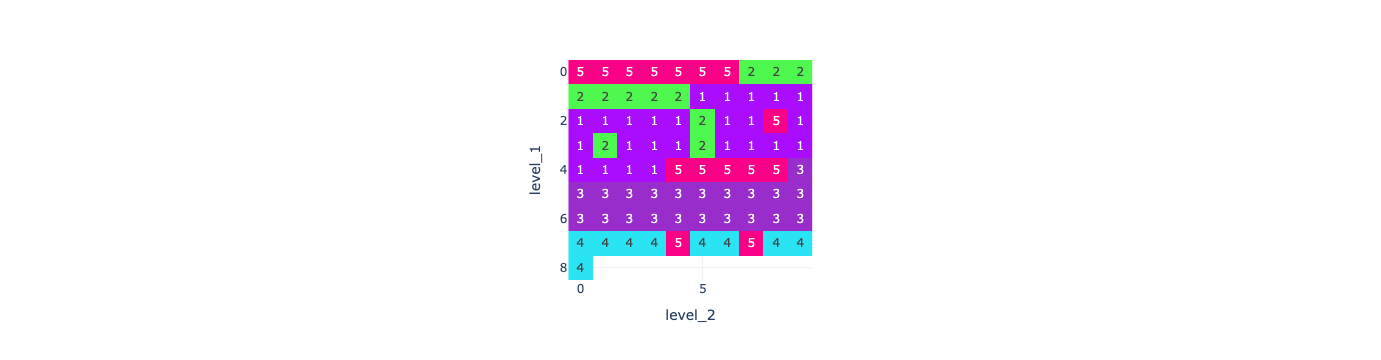

In [615]:
plot_grid(CHUNK.topic_group.unstack())

# Correlate Documents in Topic Space

In [616]:
X = THETA.T.corr()

In [617]:
fig2 = HAC(X)
fig2.linkage_method = linkage
fig2.dist_metric = metric

In [618]:
fig2.color_thresh = 2

<Figure size 640x480 with 0 Axes>

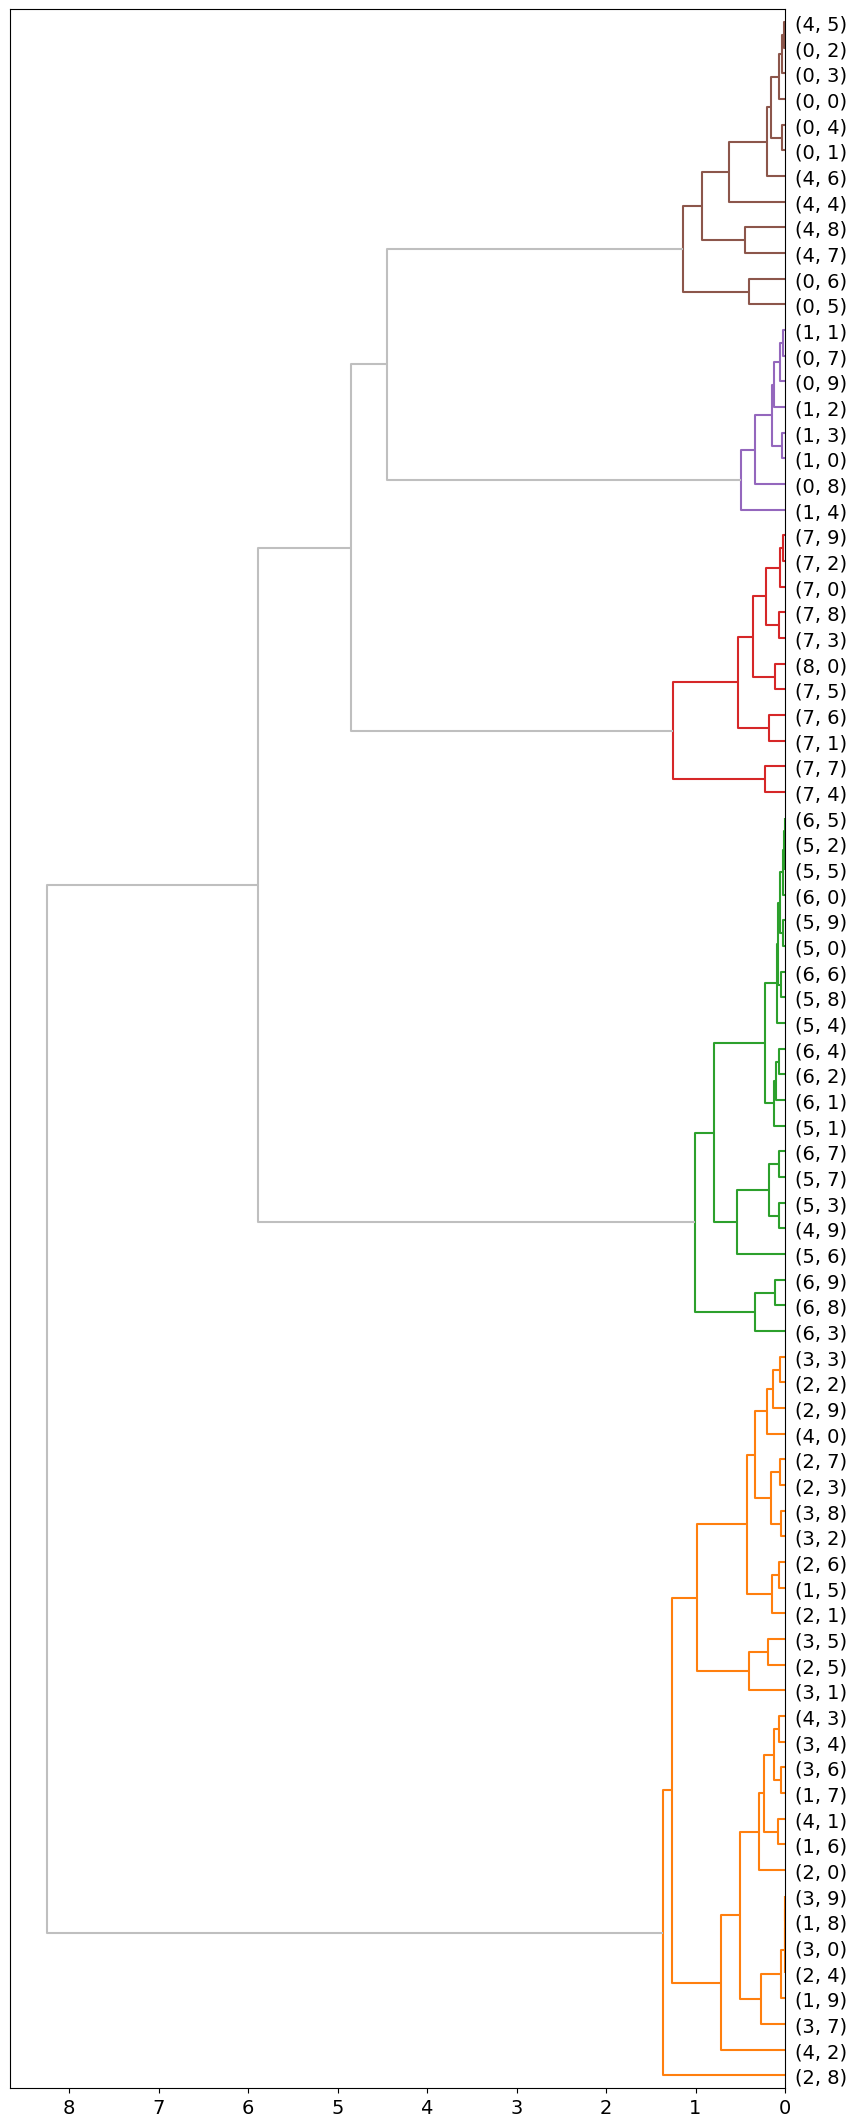

In [619]:
fig2.plot()

In [620]:
fig2.get_cluster_labels()
CHUNK['topic_group_corr'] = fig2.CLUSTER_LABELS
CHUNK.topic_group_corr = CHUNK.topic_group.astype(str)

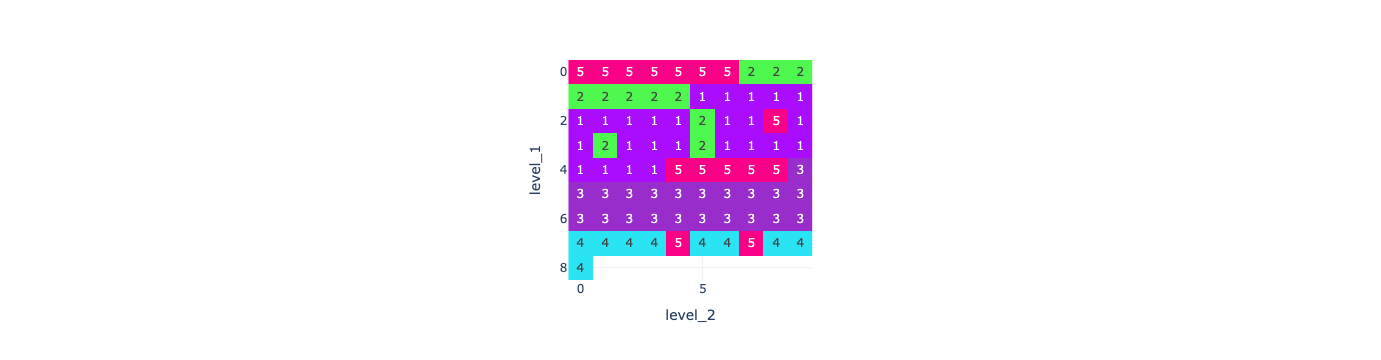

In [621]:
plot_grid(CHUNK.topic_group_corr.unstack())

# Document Similarity Heatmap

In [622]:
from sklearn.metrics.pairwise import cosine_similarity

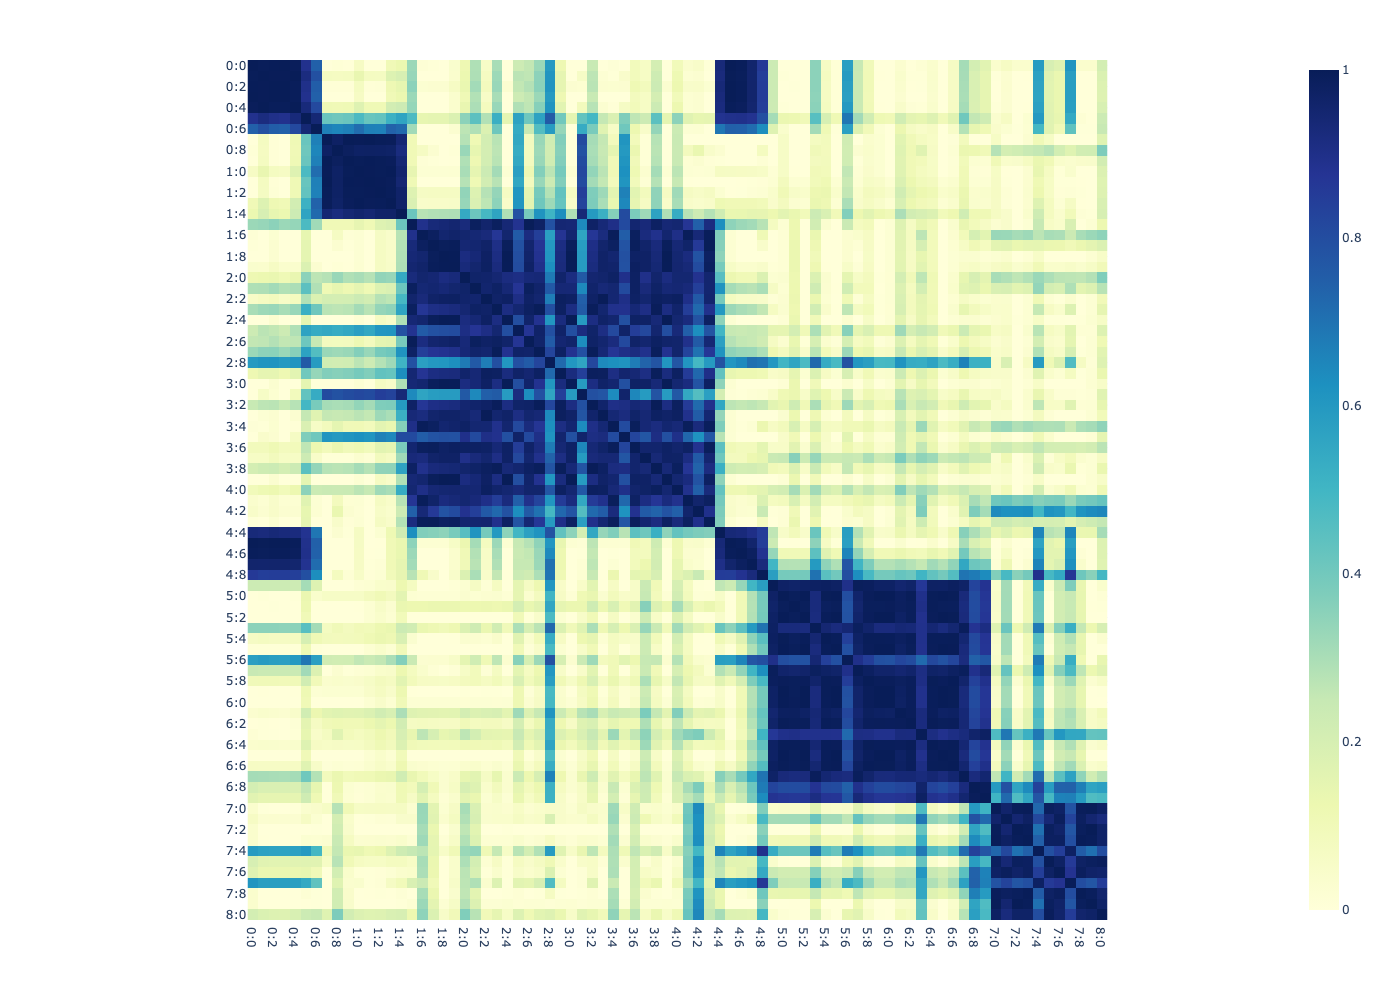

In [623]:
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)
f = CHM(THETA_SIM)
f.cmap = px.colors.colorbrewer.YlGnBu
f.plot()

# Document Correlation Heatmap

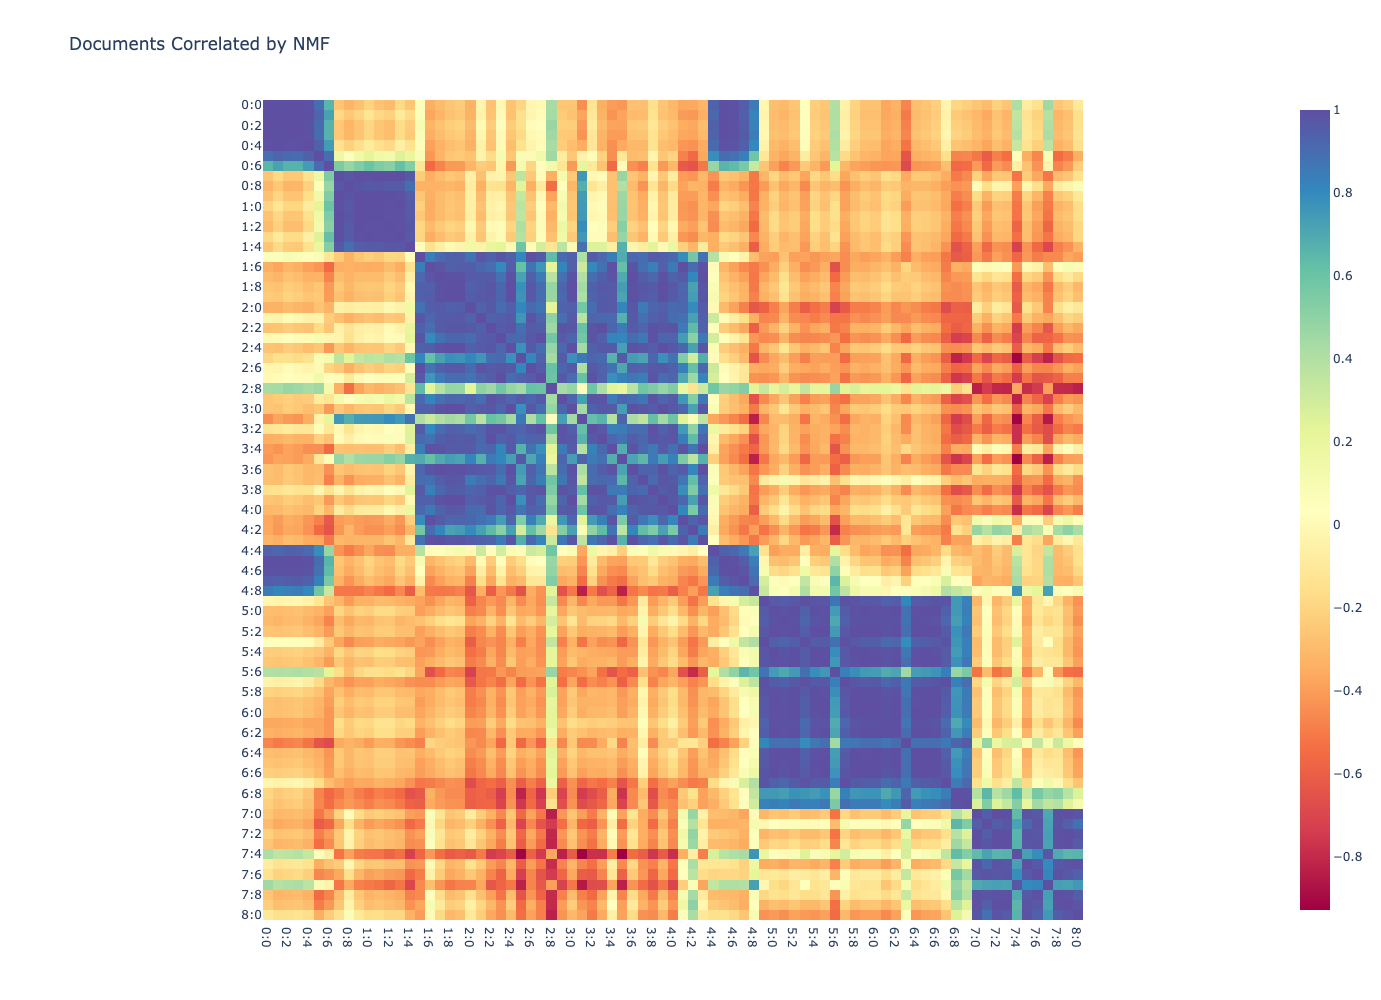

In [624]:
CHM(X, "Documents Correlated by NMF").plot()